# Paper II Methodology with Synthetic DS2

This notebook presents the Paper II analysis methods and generates the corresponding tables and figures based on the public synthetic replacement datasets `DS2_full` and `DS2_Scheil`.

Paper II:
*Øien, Christian Dalheim; Myhr, Ole Runar; Ringen, Geir. Towards hybrid
modelling of aluminium extrusion mechanical properties – A univariate
representation of artificial aging. Materials Research Proceedings 54 (2025),
819–828.
DOI: https://doi.org/10.21741/9781644903599-88*

The purpose is to evaluate the Scheil integral as a compact representation of artificial aging in Al–Mg–Si tensile-property modelling. This notebook presents the methods and comparison logic, as well as creating corresponding figures, using `DS2_full` and `DS2_Scheil`.

## 1. Setup

Import dependencies, define input files, configure plotting, and load the full and Scheil-reduced DS2 datasets.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150 # 300 used in paper
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from datetime import datetime as dt
import os
import math

from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 90)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', 800)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
ds2_full = pd.read_excel(DATA_DIR / "DS2_full.xlsx", index_col=0)
ds2_scheil = pd.read_excel(DATA_DIR / "DS2_scheil.xlsx", index_col=0)

CHEMISTRY_COLS = ["Mg [wt.%]", "Si [wt.%]", "Fe [wt.%]", "Mn [wt.%]", "Cu [wt.%]", "Cr [wt.%]"]
AGING_COLS = ["T6", "T7", "T8", "T9", "T10", "t6_7", "t7_8", "t8_9", "t9_10", "Scheil"]
FULL_FEATURES = CHEMISTRY_COLS + AGING_COLS
SCHEIL_FEATURES = CHEMISTRY_COLS + ["Scheil"]

Y_COLS = ["Rm [MPa]", "Rp0.2 [MPa]"]

In [3]:
ds2_full

,Mg [wt.%],Si [wt.%],Fe [wt.%],Mn [wt.%],Cu [wt.%],Cr [wt.%],T6,T7,T8,T9,T10,t6_7,t7_8,t8_9,t9_10,Scheil,Rp0.2 [MPa],Rm [MPa]
id,,,,,,,,,,,,,,,,,,
1,0.435,0.485,0.214,0.206,0.042,0.000,20,150,150,180,180,600,60,480,60,0.010,141.500,211.400
2,0.435,0.485,0.214,0.206,0.042,0.000,20,155,155,180,180,600,120,540,60,0.012,132.100,187.900
3,0.435,0.485,0.214,0.206,0.042,0.000,20,160,160,185,185,600,300,300,60,0.013,143.700,211.800
4,0.435,0.485,0.214,0.206,0.042,0.000,20,150,150,185,185,600,60,480,120,0.016,136.800,198.100
5,0.435,0.485,0.214,0.206,0.042,0.000,20,155,155,190,190,600,120,300,120,0.019,160.800,212.700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986,0.549,0.646,0.204,0.060,0.013,0.000,20,170,170,210,210,600,900,194820,600,21.492,222.600,296.800
2987,0.549,0.646,0.204,0.060,0.013,0.000,20,205,205,20,20,7200,132600,60,60,30.861,214.300,280.200
2988,0.549,0.646,0.204,0.060,0.013,0.000,20,200,200,20,20,7200,277860,60,60,45.667,222.700,287.900


## 2. Model settings

XGBoost hyperparameters are set according to the Paper I notebook given that `../paper_I/data/paper_I_xgb_hyperparameters.json` is available. 

If the file is absent, the original parameter set, based on D1-optimization, is used:  `objective="reg:squarederror"`, `subsample=0.8`, `colsample_bytree=0.5`, `alpha=0.1`, `lambda=0.9`, `gamma=0.01`, `learning_rate=0.08`, `max_depth=4`, and `n_estimators=500`.

In [4]:
import json

PUBLISHED_XGB_PARAMS = {
  "objective": "reg:squarederror",
  "subsample": 0.8,
  "colsample_bytree": 0.5,
  "alpha": 0.1,
  "lambda": 0.9,
  "gamma": 0.01,
  "learning_rate": 0.08,
  "max_depth": 4,
  "n_estimators": 500,
}

PAPER_I_XGB_PARAM_FILE = Path("../paper_I/data/paper_I_xgb_hyperparameters.json")
if PAPER_I_XGB_PARAM_FILE.exists():
    with PAPER_I_XGB_PARAM_FILE.open("r", encoding="utf-8") as f:
        cached_xgb_params = json.load(f)
    XGB_PARAMS = dict(cached_xgb_params["best_params"])
    xgb_param_source = f"Loaded Paper I tuned XGBoost parameters from {PAPER_I_XGB_PARAM_FILE}"
else:
    XGB_PARAMS = dict(PUBLISHED_XGB_PARAMS)
    xgb_param_source = "Using published Paper II XGBoost parameters"

print(xgb_param_source)
hyperparam_table = pd.DataFrame({
    "Hyperparameter": list(XGB_PARAMS.keys()),
    "Value": list(XGB_PARAMS.values())
})
hyperparam_table


Loaded Paper I tuned XGBoost parameters from ..\paper_I\data\paper_I_xgb_hyperparameters.json


,Hyperparameter,Value
0,objective,reg:squarederror
1,random_state,42
2,subsample,0.900
3,colsample_bytree,0.800
4,alpha,0.100
5,lambda,1.000
6,gamma,0.100
7,learning_rate,0.080
8,max_depth,3
9,n_estimators,500


## 3. Helper functions

Define plotting, binning, model-fitting, cross-validation, and metric-summary utilities used throughout the notebook.

In [5]:
def round_to_half(x):
    return round(x * 2) / 2

def round_to_thirds(x):
    return round(x * 3) / 3

def round_to_quarters(x):
    return round(x * 4) / 4

def boxplot_with_annotations_variable_width(df, x_label, y_label, ax):
    sizes = df.groupby([x_label])[y_label].size().values
    boxplot = sns.boxplot(
        data=df,
        x=x_label,
        y=y_label,
        color='w',
        linecolor='k',
        ax=ax,
        width=np.sqrt(sizes) / 30
    )
    ax.grid(color='lightgrey')
    medians = df.groupby([x_label])[y_label].median().values
    vertical_offsets = df[y_label].median() * -0.1
    for xtick in boxplot.get_xticks():
        boxplot.text(
            xtick,
            medians[xtick] + vertical_offsets,
            round(medians[xtick], 1),
            horizontalalignment='center',
            size='small',
            color='k'
        )
    return None

def boxplot_with_annotations(df, x_label, y_label, offset_factor, round_digits, ax):
    boxplot = sns.boxplot(
        data=df,
        x=x_label,
        y=y_label,
        color='w',
        linecolor='k',
        ax=ax
    )
    ax.grid(color='lightgrey')
    medians = df.groupby([x_label])[y_label].median().values
    vertical_offsets = df[y_label].median() * offset_factor
    for xtick in boxplot.get_xticks():
        boxplot.text(
            xtick,
            medians[xtick] + vertical_offsets,
            round(medians[xtick], round_digits),
            horizontalalignment='center',
            size='small',
            color='k'
        )
    return None

## 4. Equivalent isothermal aging time

Calculate equivalent isothermal aging duration as a function of temperature and generate Figure 1.

This provides the basis for converting non-isothermal artificial-aging cycles into a Scheil integral.

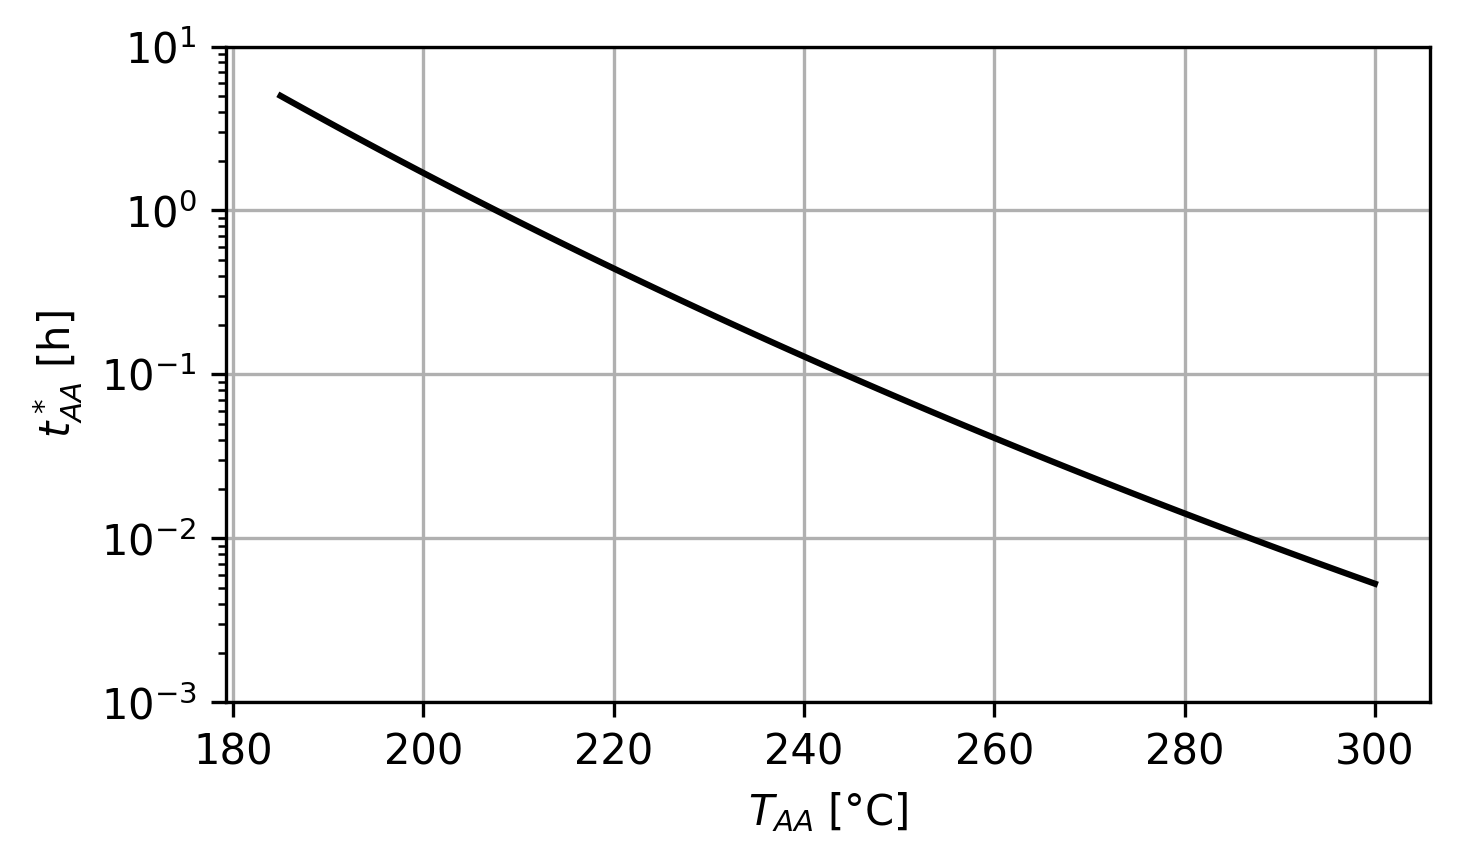

In [6]:
Q = 130000
R = 8.314
T_r = 185 + 273

temps = np.linspace(185 + 273, 300 + 273, 100)
t_r = 5 * 3600
ts = t_r * np.exp((Q / R) * ((1 / temps) - (1 / T_r)))

plt.plot(temps - 273, ts / 3600, linestyle='-', c='k')
plt.grid()
plt.ylim(0.001, 10)
plt.ylabel('$t^*_{AA}$ [h]')
plt.xlabel('$T_{AA}$ [°C]')
plt.yscale('log')
plt.gcf().set_size_inches(5, 3)
plt.tight_layout()
plt.show()

def aging_time(temp):
    T_r = 185 + 273
    t_r = 5 * 3600
    Q = 130000
    R = 8.314
    return t_r * np.exp((Q / R) * ((1 / temp) - (1 / T_r)))

## 5. Relative yield strength versus Scheil integral

Group experiments by alloy chemistry, normalize each `Rp0.2` value by the maximum strength within its chemistry series, and plot relative yield strength against `log I`.

This checks whether `I ≈ 1` corresponds to peak-aged behavior across different alloys and aging cycles.

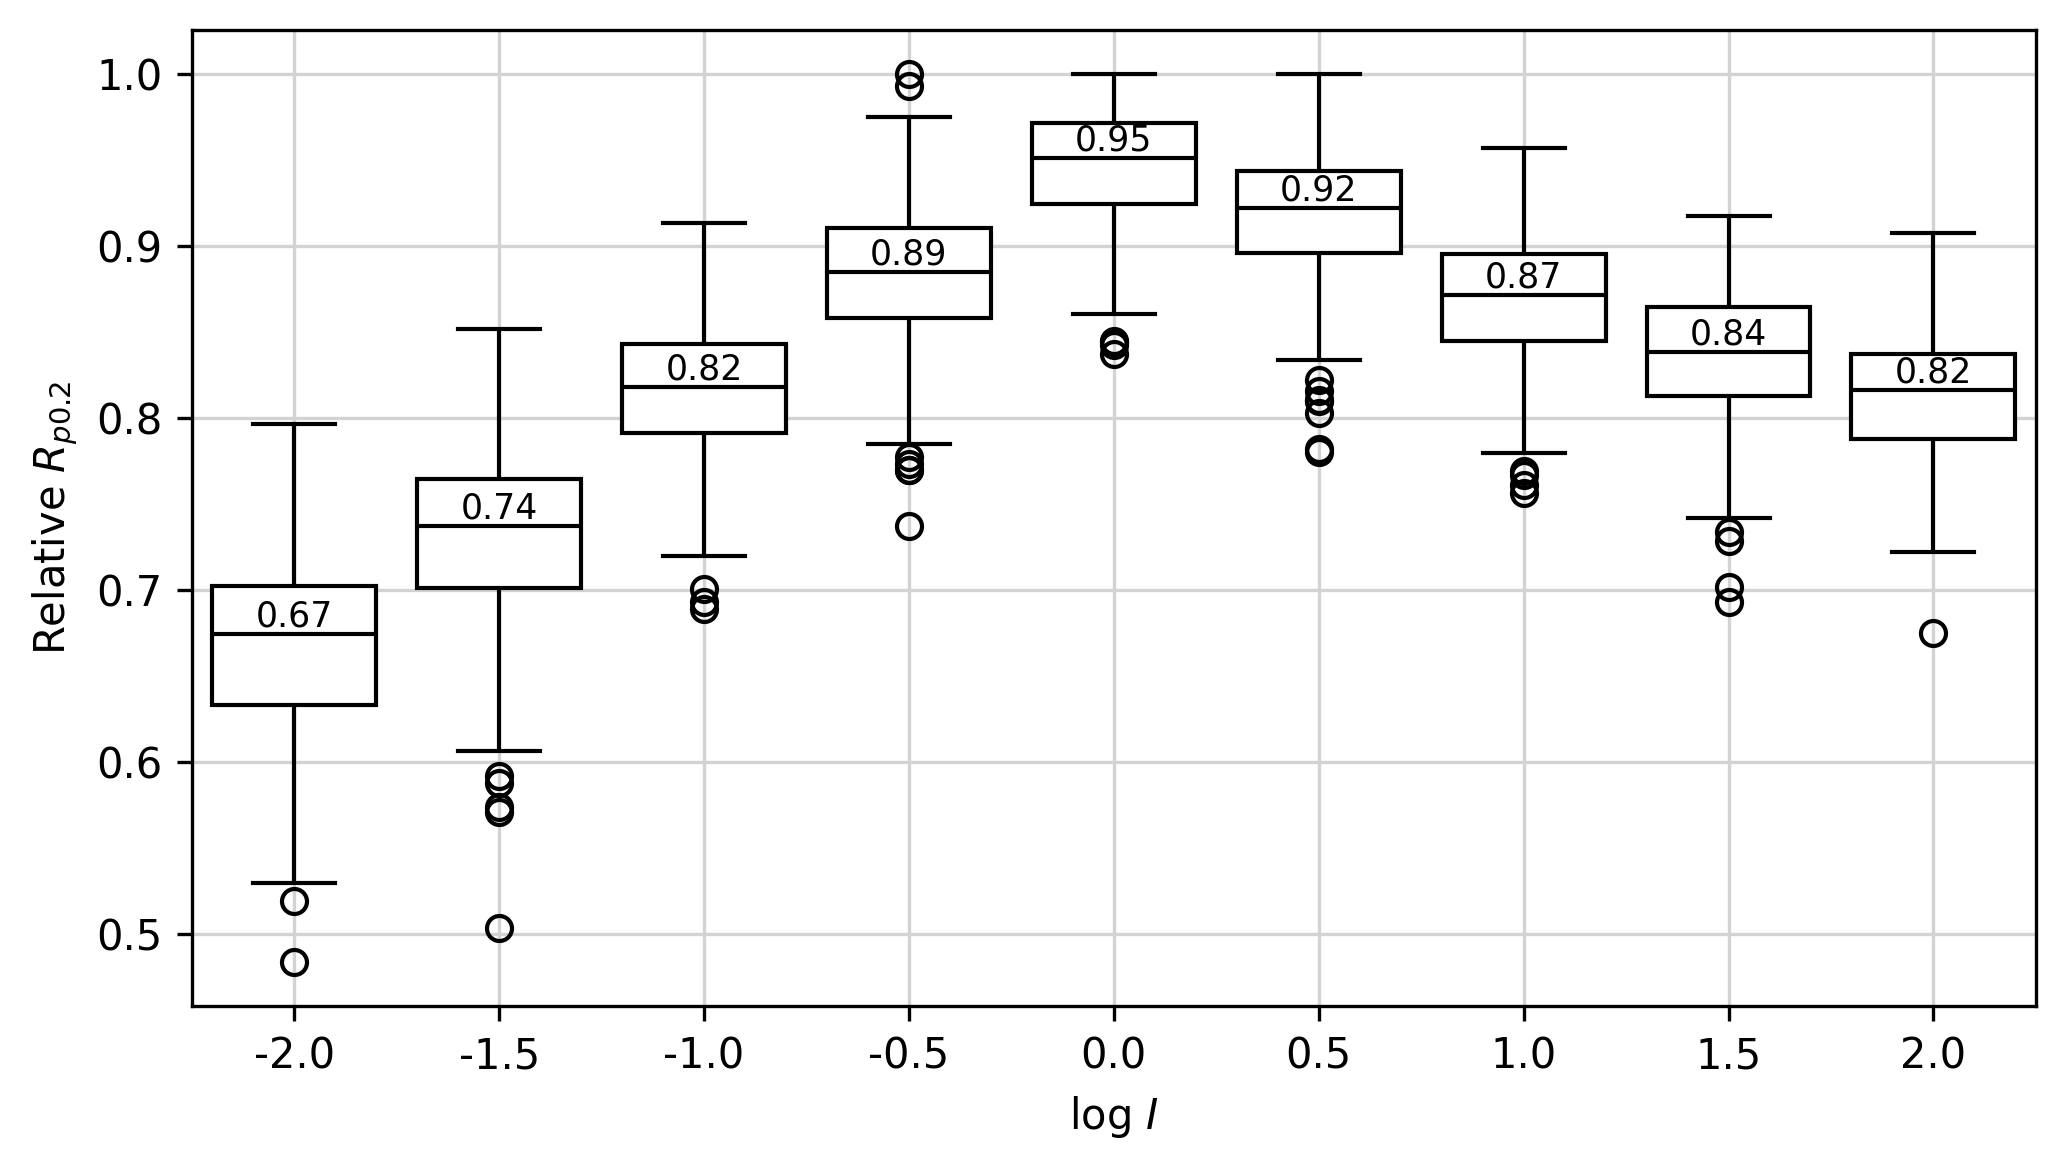

In [7]:
df = ds2_scheil.copy()
df['log Scheil'] = np.log10(df['Scheil'])

# Synthetic adaptation:
# In the original notebook, ageing groups are inferred from sequence structure.
# Here, each unique chemistry acts as one ageing group.
df['ageing_group'] = pd.factorize(df[CHEMISTRY_COLS].apply(tuple, axis=1))[0]
df['group_size'] = df.groupby('ageing_group')['ageing_group'].transform('count').astype(int)

df['rp02 group max'] = -1.0
df['T6 Scheil'] = -1.0

for group_no in df['ageing_group'].unique():
    df_temp = df.loc[df['ageing_group'] == group_no]
    max_rp02 = df_temp['Rp0.2 [MPa]'].max()
    t6_scheil = df_temp.loc[df_temp['Rp0.2 [MPa]'] == max_rp02, 'log Scheil'].values[0]
    df.loc[df['ageing_group'] == group_no, 'rp02 group max'] = max_rp02
    df.loc[df['ageing_group'] == group_no, 'T6 Scheil'] = t6_scheil

df['rp02 group diff'] = df['Rp0.2 [MPa]'] - df['rp02 group max']
df['rp02 group factor'] = df['Rp0.2 [MPa]'] / df['rp02 group max']

# Keep the same filtering logic as in 00b_scheil_investigation_norm.ipynb
df = df.loc[df['T6 Scheil'] < 5]
df = df.loc[df['group_size'] > 4]

df_chem_groups = []
for group in df['ageing_group'].unique():
    df_temp = df.loc[df['ageing_group'] == group]
    temp_chem = (
        df_temp.groupby(CHEMISTRY_COLS)
        .size()
        .reset_index()
        .rename(columns={0: 'count'})
    )
    if len(temp_chem) == 1:
        if len(df_temp) > 7:
            df_chem_groups.append(df_temp)

df_chem_groups = pd.concat(df_chem_groups)

df_rounded_scheil = df_chem_groups.copy()
df_rounded_scheil['log Scheil'] = df_rounded_scheil['log Scheil'].apply(round_to_half)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 4))
boxplot_with_annotations(df_rounded_scheil, 'log Scheil', 'rp02 group factor', 0.005, 2, ax=ax)

plt.xlabel('log $I$')
plt.ylabel('Relative $R_{p0.2}$')
plt.tight_layout()
plt.show()

## 6. Scheil integral at peak strength

Identify the aging condition giving maximum `Rp0.2` within each chemistry series and plot the corresponding `log I` against aging temperature.

This tests whether peak-strength conditions remain close to `I = 1` across different holding temperatures.

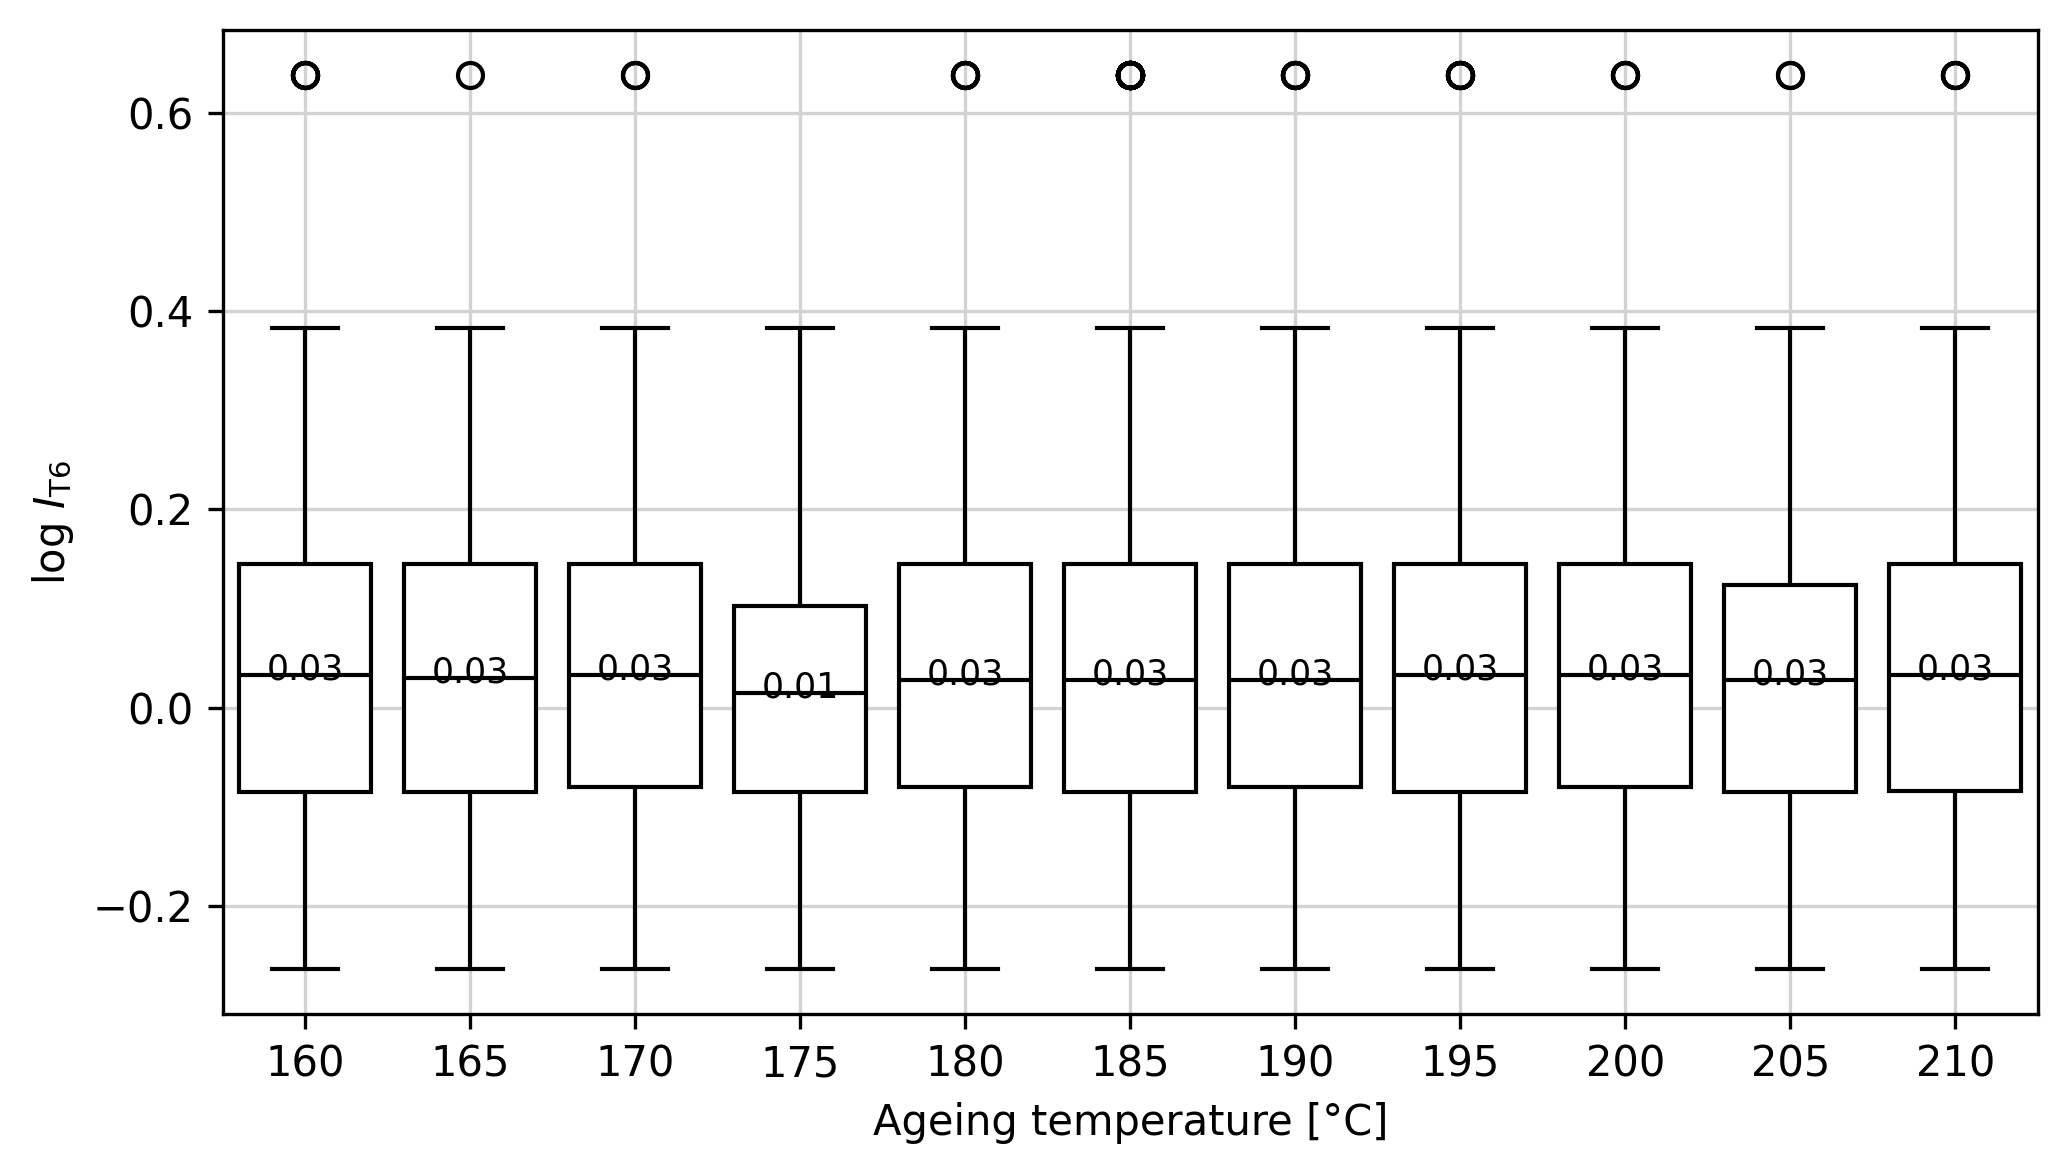

In [8]:
df = ds2_full.copy()
df['log Scheil'] = np.log10(df['Scheil'])

# Synthetic adaptation of the original "Ageing_holding_temperature"
# For type1/type2 synthetic cycles, this corresponds to the maximum imposed AA temperature.
df['Ageing_holding_temperature'] = df[['T7', 'T8', 'T9', 'T10']].max(axis=1)

df['ageing_group'] = pd.factorize(df[CHEMISTRY_COLS].apply(tuple, axis=1))[0]
df['group_size'] = df.groupby('ageing_group')['ageing_group'].transform('count').astype(int)

df['rp02 group max'] = -1.0
df['T6 Scheil'] = -1.0

for group_no in df['ageing_group'].unique():
    df_temp = df.loc[df['ageing_group'] == group_no]
    max_rp02 = df_temp['Rp0.2 [MPa]'].max()
    t6_scheil = df_temp.loc[df_temp['Rp0.2 [MPa]'] == max_rp02, 'log Scheil'].values[0]
    df.loc[df['ageing_group'] == group_no, 'rp02 group max'] = max_rp02
    df.loc[df['ageing_group'] == group_no, 'T6 Scheil'] = t6_scheil

df = df.loc[df['T6 Scheil'] < 5]
df = df.loc[df['group_size'] > 4]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 4))
boxplot_with_annotations(df, 'Ageing_holding_temperature', 'T6 Scheil', -0.15, 2, ax=ax)

plt.xlabel('Ageing temperature [°C]')
plt.ylabel('log $I_{\\mathrm{T6}}$')
plt.tight_layout()
plt.show()

## 7. Full aging input versus Scheil-only input

Train and evaluate two XGBoost representations using sequential 5-fold cross-validation:

- full aging-cycle representation
- Scheil-only aging representation

The comparison evaluates the Scheil integral-based dimensionality reduction from several aging variables to one synthetic feature.

In [9]:
def fit_model(X_train, X_test, y_train, y_test, y_cols, params, note):
    start_time = dt.now()
    reg = xgb.XGBRegressor(**params)
    reg.fit(X_train, y_train)
    training_time = (dt.now() - start_time).total_seconds()

    y_test_estimated = reg.predict(X_test)

    res_values = [note]
    res_labels = ['Note']

    res_values.append(reg.score(X_test, y_test))
    res_labels.append('R2')

    for i in range(y_test.shape[1]):
        label = y_cols[i]

        r2 = r2_score(y_test[:, i], y_test_estimated[:, i])
        rmse = np.sqrt(mean_squared_error(y_test[:, i], y_test_estimated[:, i]))

        res_values.append(r2)
        res_labels.append(label + ' R2')
        res_values.append(rmse)
        res_labels.append(label + ' RMSE')

    for key in params.keys():
        res_values.append(params[key])
        res_labels.append(key)

    res_values.append(training_time)
    res_labels.append('Training time')

    df_tmp = pd.DataFrame([res_values], columns=res_labels)
    return reg, df_tmp


def run_sequential_cv_original_method(df, x_cols, y_cols, params, representation_name):
    df_y = df.loc[:, y_cols].copy()
    df_y = df_y[pd.to_numeric(df_y['Rp0.2 [MPa]'], errors='coerce').notnull()]
    df_y = df_y[pd.to_numeric(df_y['Rm [MPa]'], errors='coerce').notnull()]

    df_X = df.loc[:, x_cols].copy()
    df_X = df_X.loc[df_y.index]

    # Homologated to 03b_XGBoost_Scheil_UT_full.ipynb:
    # normalize once on the full dataset, before making sequential CV folds
    df_X_norm = (df_X - df_X.mean()) / df_X.std()

    [n, m] = df_X.shape
    cvs = [0, int(n * 0.2), int(n * 0.4), int(n * 0.6), int(n * 0.8), n]

    X_norm = df_X_norm.to_numpy()
    y = df_y.to_numpy()

    fit_results = pd.DataFrame()
    prediction_folds = {}

    for i, (start, stop) in enumerate(zip(cvs, cvs[1:])):
        X_train = np.concatenate((X_norm[0:start, :], X_norm[stop:, :]))
        X_test = X_norm[start:stop, :]
        y_train = np.concatenate((y[0:start, :], y[stop:, :]))
        y_test = y[start:stop, :]

        note = f'{representation_name}, cv{i}'
        reg, df_tmp = fit_model(X_train, X_test, y_train, y_test, y_cols, params, note)
        fit_results = pd.concat([fit_results, df_tmp], ignore_index=True)

        y_test_xgb = reg.predict(X_test)

        y_test_df = pd.DataFrame({
            'Rp02_xgb': y_test_xgb[:, 1],
            'Rm_xgb': y_test_xgb[:, 0],
            'Rp0.2 [MPa]': y_test[:, 1],
            'Rm [MPa]': y_test[:, 0],
        })
        prediction_folds[i] = y_test_df

    return fit_results, prediction_folds


full_fit_results, full_prediction_folds = run_sequential_cv_original_method(
    ds2_full,
    FULL_FEATURES,
    Y_COLS,
    XGB_PARAMS,
    'a) full aging representation'
)

scheil_fit_results, scheil_prediction_folds = run_sequential_cv_original_method(
    ds2_scheil,
    SCHEIL_FEATURES,
    Y_COLS,
    XGB_PARAMS,
    'b) Scheil representation'
)

## 8. Cross-validation summary

Summarize `R²` and RMSE for `Rp0.2` and `Rm` across the sequential folds, including confidence intervals based on fold-to-fold variation.

In [10]:
def summarize_fit_results(fit_results, representation_name):
    rp02_rmses = fit_results['Rp0.2 [MPa] RMSE'].astype(float)
    rm_rmses = fit_results['Rm [MPa] RMSE'].astype(float)
    rp02_r2s = fit_results['Rp0.2 [MPa] R2'].astype(float)
    rm_r2s = fit_results['Rm [MPa] R2'].astype(float)

    return pd.DataFrame([
        {
            'representation': representation_name,
            'target': 'Rp0.2 [MPa]',
            'R2': f'{rp02_r2s.mean():0.2f} +/- {rp02_r2s.std(ddof=1) * 2:0.2f}',
            'RMSE [MPa]': f'{rp02_rmses.mean():0.1f} +/- {rp02_rmses.std(ddof=1) * 2:0.1f}',
        },
        {
            'representation': representation_name,
            'target': 'Rm [MPa]',
            'R2': f'{rm_r2s.mean():0.2f} +/- {rm_r2s.std(ddof=1) * 2:0.2f}',
            'RMSE [MPa]': f'{rm_rmses.mean():0.1f} +/- {rm_rmses.std(ddof=1) * 2:0.1f}',
        },
    ])

paper_table = pd.concat([
    summarize_fit_results(full_fit_results, 'a) full aging representation'),
    summarize_fit_results(scheil_fit_results, 'b) Scheil representation'),
], ignore_index=True)

paper_table = paper_table.pivot(
    index='representation',
    columns='target',
    values=['R2', 'RMSE [MPa]']
)

paper_table

R2                   RMSE [MPa]             
target                             Rm [MPa]    Rp0.2 [MPa]      Rm [MPa]  Rp0.2 [MPa]
representation                                                                       
a) full aging representation  0.95 +/- 0.01  0.96 +/- 0.02  11.1 +/- 1.6  9.5 +/- 1.2
b) Scheil representation      0.95 +/- 0.01  0.96 +/- 0.01  10.6 +/- 0.8  9.0 +/- 1.0

## 9. Measured versus predicted strengths

Plot measured against predicted `Rp0.2` and `Rm` for one Scheil-representation fold.

This performs the Figure 4 check of model accuracy when artificial aging is represented by the Scheil integral alone.

C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_36940\665197447.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


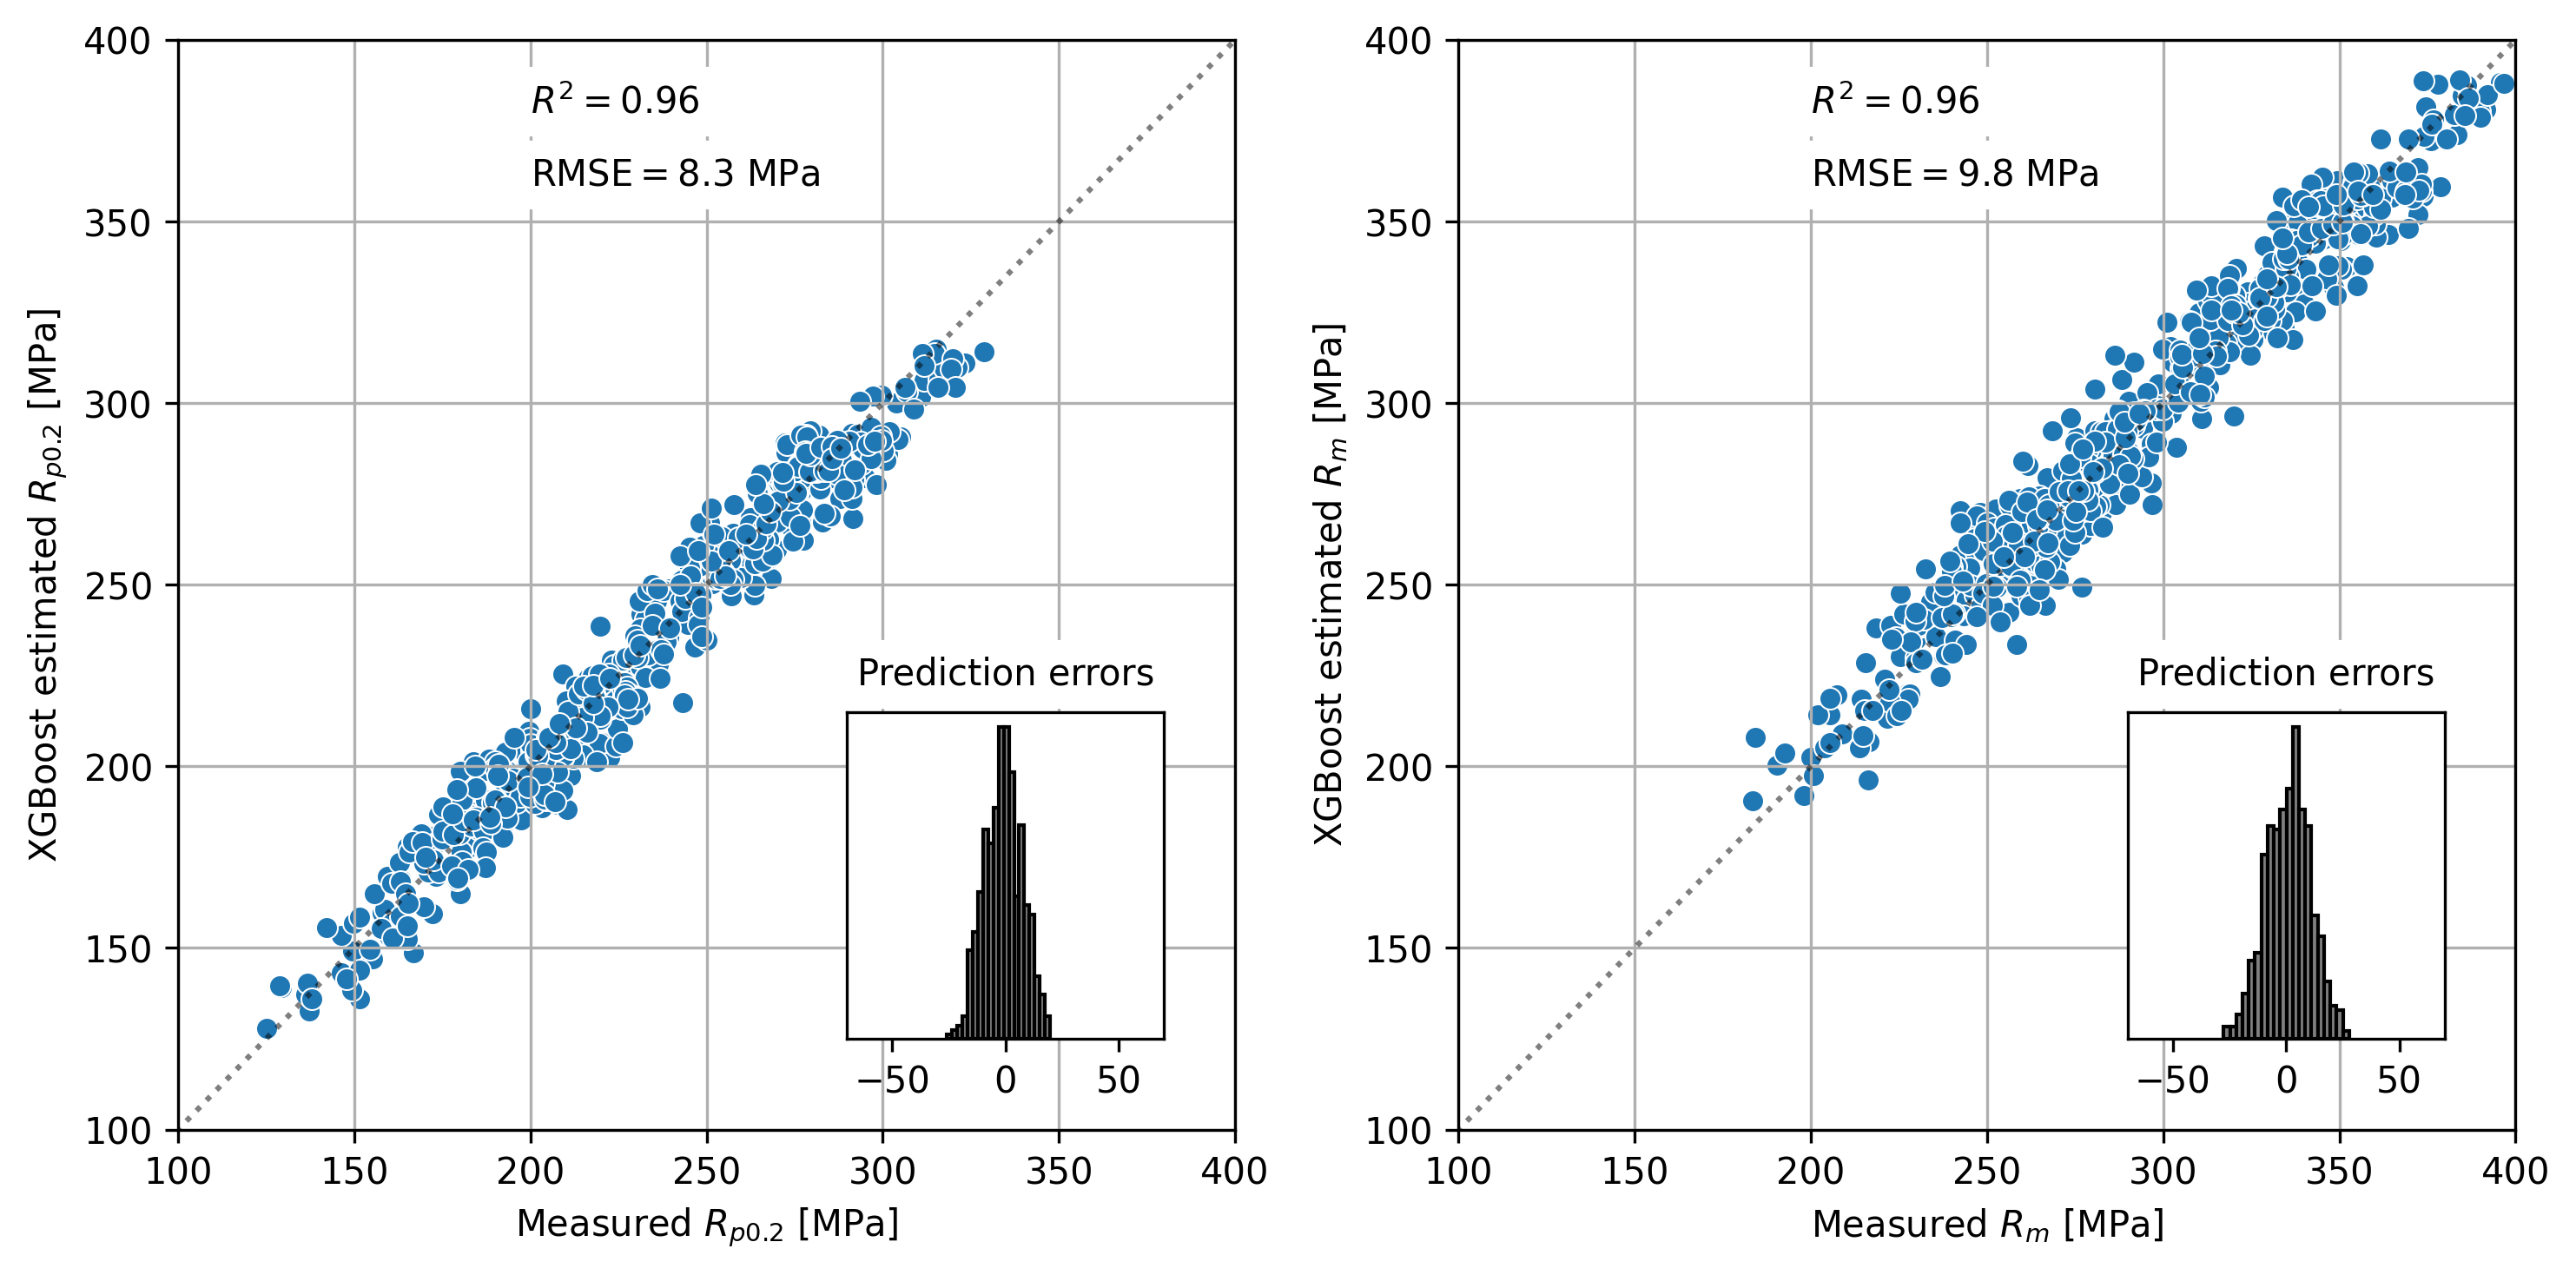

In [11]:
def model_eval_plot(df, true_col, pred_col, x_label, y_label, ax):
    plt.sca(ax)
    sns.scatterplot(x=true_col, y=pred_col, data=df)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.plot([0, 400], [0, 400], linestyle='dotted', color='black', alpha=0.5)
    plt.xlim(100, 400)
    plt.ylim(100, 400)
    plt.grid()

    rmse = np.sqrt(mean_squared_error(df[true_col], df[pred_col]))
    r2 = r2_score(df[true_col], df[pred_col])
    xy1 = (200, 380)
    xy2 = (200, 360)
    _ = plt.annotate(f'$R^2={r2:0.2f}$', xy=xy1, xytext=xy1, backgroundcolor="w")
    _ = plt.annotate(f'RMSE$={rmse:0.1f}$ MPa', xy=xy2, xytext=xy2, backgroundcolor="w")

    axins = inset_axes(
        ax,
        width="100%",
        height="100%",
        bbox_to_anchor=(.65, .1, .3, .3),
        bbox_transform=ax.transAxes
    )
    error = df[pred_col] - df[true_col]
    error.hist(ec='black', linewidth=1, ax=axins, color='gray', bins=20)
    axins.grid(False)
    axins.set_ylim(0)
    axins.set_xlim(-70, 70)
    axins.set_ylabel('')
    axins.set_yticks([])
    axins.set_title('Prediction errors', fontsize=10, backgroundcolor="w", pad=7.5)


example_df = scheil_prediction_folds[2]

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 5))

model_eval_plot(
    example_df,
    'Rp0.2 [MPa]',
    'Rp02_xgb',
    'Measured $R_{p0.2}$ [MPa]',
    'XGBoost estimated $R_{p0.2}$ [MPa]',
    ax1
)
model_eval_plot(
    example_df,
    'Rm [MPa]',
    'Rm_xgb',
    'Measured $R_m$ [MPa]',
    'XGBoost estimated $R_m$ [MPa]',
    ax2
)

plt.tight_layout()
plt.show()